# Derivatives, Partial Derivatives และ Gradient สำหรับ Machine Learning — เรียนด้วย NumPy ทีละขั้น

**ระดับ:** ปานกลาง • **เวลาประมาณ:** 75–100 นาที แบ่งเรียนได้ 2–3 รอบ • **ภาษา:** ไทย พร้อมศัพท์อังกฤษที่ใช้จริง

บทเรียนนี้ใช้ตัวอย่าง โค้ด และภาพที่สร้างขึ้นใหม่ทั้งหมด ต่อยอดจาก `01_vectors_and_matrices.ipynb`
และ `02_matrix_operations.ipynb` — จาก derivative ตัวแปรเดียว ไปสู่ partial derivative, gradient vector
และ gradient descent ซึ่งเป็นกลไกที่โมเดล ML เกือบทุกแบบใช้เรียนรู้จากข้อมูล

**ก่อนเริ่ม:** ควรผ่าน `01_vectors_and_matrices.ipynb` มาก่อน (คุ้นเคยกับ vector, matrix multiplication,
broadcasting) เลือก kernel `.venv` ของโครงการ แล้วใช้ **Restart Kernel → Run All**
โค้ดใช้เฉพาะแพ็กเกจที่มีในโครงการ ไม่ต้องดาวน์โหลดข้อมูล รันตามลำดับเพราะเซลล์ถัดไปใช้ตัวแปรจากเซลล์ก่อนหน้า

เมื่อเรียนจบ คุณควรอธิบายได้ว่า:
1. derivative คืออะไร และสื่อถึงอัตราการเปลี่ยนแปลงชั่วขณะอย่างไร
2. numerical differentiation (finite difference) ต่างจาก analytical differentiation อย่างไร
   และทำไม step size $h$ เล็กเกินไปก็มีปัญหา
3. partial derivative และ gradient vector คืออะไร และทำไม gradient ชี้ไปทิศทาง steepest ascent
4. chain rule เชื่อมฟังก์ชันที่ซ้อนกันอย่างไร (พื้นฐานของ backpropagation ที่จะเรียนใน Phase 09)
5. gradient descent ทำงานอย่างไร และ learning rate ส่งผลต่อการลู่เข้า/ลู่ออกอย่างไร
6. ใช้ gradient descent fit linear regression และเทียบกับ closed-form (`lstsq`) จากบทเรียนก่อนหน้า

**เส้นทาง:** ส่วน 1–3 derivative/gradient พื้นฐาน → ส่วน 4 chain rule →
ส่วน 5–7 gradient descent และ learning rate → ส่วน 8 mini-project → ส่วน 9–10 สรุปและแบบฝึกหัด

## 1. เตรียมเครื่องมือ

บทเรียนนี้ไม่มีไลบรารี autodiff ให้เทียบ (เช่น PyTorch) จึงเทียบ **analytical derivative**
(คำนวณด้วยสูตรตรงๆ) กับ **numerical derivative** (finite difference) แทน ซึ่งเป็นวิธีมาตรฐาน
สำหรับตรวจสอบว่าอนุพันธ์ที่คำนวณด้วยมือถูกต้องหรือไม่ (gradient checking)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

SEED = 42
np.set_printoptions(precision=3, suppress=True)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
thai_font = next(
    (
        name
        for name in ["Noto Sans Thai", "Tahoma", "Thonburi", "Sukhumvit Set"]
        if name in available_fonts
    ),
    None,
)
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11, "axes.unicode_minus": False})
if thai_font:
    plt.rcParams["font.family"] = thai_font


def label(thai, english):
    return thai if thai_font else english


print("NumPy:", np.__version__)
print("ฟอนต์สำหรับกราฟ:", thai_font or "English fallback")

NumPy: 2.5.3
ฟอนต์สำหรับกราฟ: Tahoma


## 2. Derivative คืออะไร

derivative ของ $f$ ที่จุด $x$ คืออัตราการเปลี่ยนแปลงชั่วขณะ (ความชันของเส้นสัมผัส) นิยามด้วยลิมิต:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}$$

ในทางปฏิบัติคอมพิวเตอร์ไม่สามารถให้ $h\to 0$ จริงๆ ได้ (มีความคลาดเคลื่อนจาก floating-point)
จึงประมาณด้วย $h$ ที่เล็กพอ เรียกว่า **numerical differentiation** วิธีที่แม่นยำกว่าการใช้แค่
$f(x+h)$ คือ **central difference** ซึ่งใช้ทั้งสองข้างของจุด:

$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$$

**ตัวอย่าง:** $f(x)=x^2$ มี derivative ที่คำนวณด้วยมือ (analytical) คือ $f'(x)=2x$

อ้างอิง: [Wikipedia — Derivative](https://en.wikipedia.org/wiki/Derivative)

f'(3) แบบ analytical: 6.0
f'(3) แบบ central difference (h=1e-05): 6.000000000039306
สองวิธีให้ค่าใกล้เคียงกันมาก — central difference ใช้ตรวจสอบ derivative ที่คำนวณด้วยมือได้


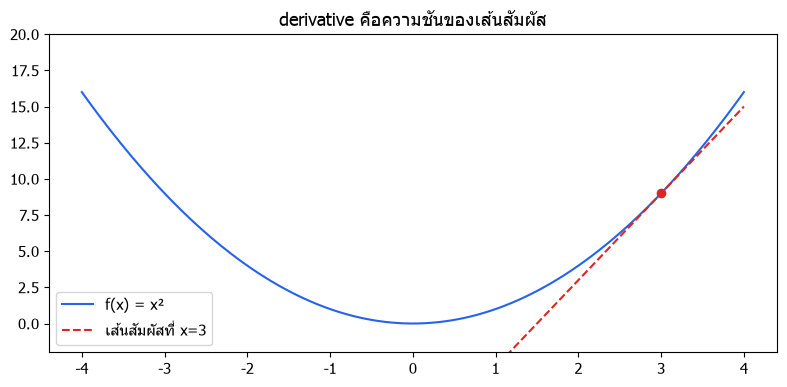

In [2]:
def f_square(x):
    return x**2


def f_square_prime(x):
    return 2 * x  # อนุพันธ์ที่คำนวณด้วยมือ (analytical)


x0 = 3.0
h = 1e-5
central_diff = (f_square(x0 + h) - f_square(x0 - h)) / (2 * h)
analytic = f_square_prime(x0)
print(f"f'(3) แบบ analytical: {analytic}")
print(f"f'(3) แบบ central difference (h={h}): {central_diff}")
np.testing.assert_allclose(central_diff, analytic, atol=1e-4)
print("สองวิธีให้ค่าใกล้เคียงกันมาก — central difference ใช้ตรวจสอบ derivative ที่คำนวณด้วยมือได้")

x_range = np.linspace(-4, 4, 200)
fig, ax = plt.subplots()
ax.plot(x_range, f_square(x_range), color="#2563eb", label="f(x) = x²")
tangent_at_x0 = analytic * (x_range - x0) + f_square(x0)
ax.plot(x_range, tangent_at_x0, "--", color="#dc2626", label=f"เส้นสัมผัสที่ x={x0:g}")
ax.scatter([x0], [f_square(x0)], color="#dc2626", zorder=5)
ax.set_ylim(-2, 20)
ax.legend()
ax.set_title(label("derivative คือความชันของเส้นสัมผัส", "Derivative is the tangent line's slope"))
plt.tight_layout()
plt.show()

## 3. Forward vs Central Difference: เลือก h อย่างไร

**Forward difference** ($\frac{f(x+h)-f(x)}{h}$) มีความคลาดเคลื่อนระดับ $O(h)$
**Central difference** มีความคลาดเคลื่อนระดับ $O(h^2)$ — เล็กกว่ามากเมื่อ $h$ เล็ก จึงนิยมใช้มากกว่า

แต่ $h$ เล็กเกินไปก็มีปัญหาอีกแบบ: floating-point มีความละเอียดจำกัด เมื่อ $h$ เล็กมากๆ
$f(x+h)-f(x-h)$ จะเป็นการลบเลขที่ใกล้เคียงกันมาก (catastrophic cancellation) ทำให้ความคลาดเคลื่อน
**เพิ่มขึ้น** อีกครั้ง ต้องเลือก $h$ ที่พอดี ไม่เล็กหรือใหญ่เกินไป

ที่ h=0.001: forward error = 4.21e-04, central error = 9.01e-08
central difference แม่นยำกว่า forward difference ที่ h เดียวกัน


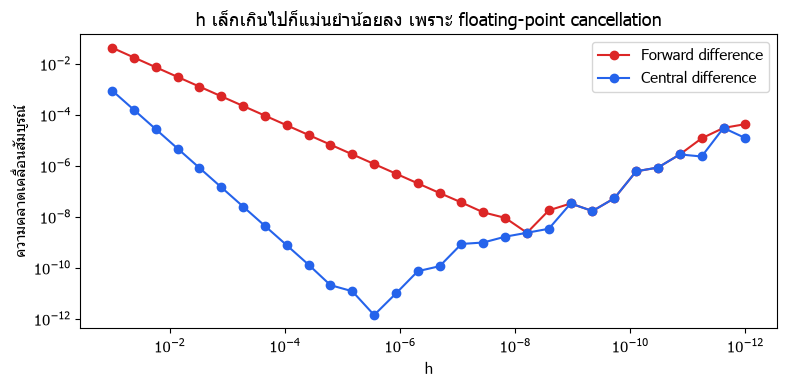

In [3]:
x1 = 1.0
true_deriv = np.cos(x1)  # d/dx sin(x) = cos(x)
hs = np.logspace(-1, -12, 30)
forward_errors = np.abs([(np.sin(x1 + hh) - np.sin(x1)) / hh - true_deriv for hh in hs])
central_errors = np.abs([(np.sin(x1 + hh) - np.sin(x1 - hh)) / (2 * hh) - true_deriv for hh in hs])

h_mid = 1e-3
fwd_mid = (np.sin(x1 + h_mid) - np.sin(x1)) / h_mid
ctr_mid = (np.sin(x1 + h_mid) - np.sin(x1 - h_mid)) / (2 * h_mid)
print(
    f"ที่ h={h_mid}: forward error = {abs(fwd_mid - true_deriv):.2e}, central error = {abs(ctr_mid - true_deriv):.2e}"
)
assert abs(ctr_mid - true_deriv) < abs(fwd_mid - true_deriv)
print("central difference แม่นยำกว่า forward difference ที่ h เดียวกัน")

fig, ax = plt.subplots()
ax.loglog(hs, forward_errors, "o-", label="Forward difference", color="#dc2626")
ax.loglog(hs, central_errors, "o-", label="Central difference", color="#2563eb")
ax.set_xlabel("h")
ax.set_ylabel(label("ความคลาดเคลื่อนสัมบูรณ์", "Absolute error"))
ax.invert_xaxis()
ax.legend()
ax.set_title(
    label(
        "h เล็กเกินไปก็แม่นยำน้อยลง เพราะ floating-point cancellation", "Too-small h also hurts accuracy"
    )
)
plt.tight_layout()
plt.show()

## 4. Partial Derivative และ Gradient Vector

สำหรับฟังก์ชันหลายตัวแปร $f(x,y)$ **partial derivative** คืออนุพันธ์เทียบกับตัวแปรหนึ่งตัว
โดยตรึงตัวแปรอื่นไว้คงที่ เขียนเป็น $\frac{\partial f}{\partial x}$ และ $\frac{\partial f}{\partial y}$

**Gradient vector** คือเวกเตอร์ที่รวม partial derivative ทุกตัวแปรไว้ด้วยกัน:

$$\nabla f(x,y) = \begin{pmatrix}\partial f/\partial x \\ \partial f/\partial y\end{pmatrix}$$

**ความหมายสำคัญ:** $\nabla f$ ชี้ไปทิศทางที่ $f$ เพิ่มขึ้นเร็วที่สุด (steepest ascent) และตั้งฉากกับ
เส้น contour ของ $f$ เสมอ — เป็นแนวคิดหลักที่ gradient descent (ส่วน 6) ใช้ประโยชน์

**ตัวอย่าง:** $f(x,y)=x^2+y^2$ มี $\nabla f = [2x, 2y]$

อ้างอิง: [Wikipedia — Gradient](https://en.wikipedia.org/wiki/Gradient)

gradient (analytical): [6. 8.]
gradient (numerical):  [6. 8.]


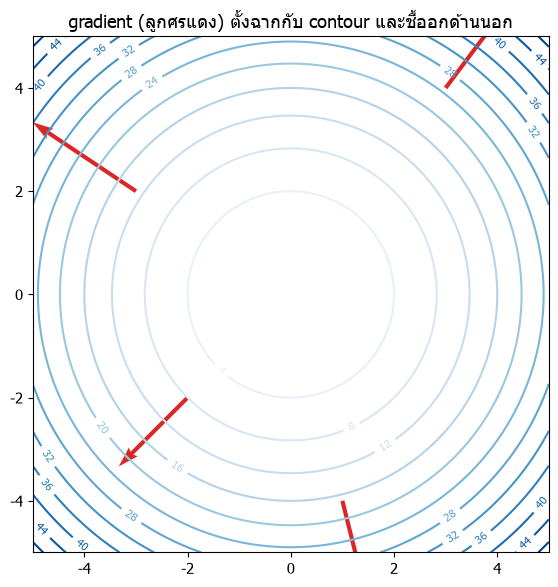

In [4]:
def f_bowl(x, y):
    return x**2 + y**2


def grad_f_bowl_analytic(x, y):
    return np.array([2 * x, 2 * y])


def grad_f_bowl_numeric(x, y, h=1e-5):
    df_dx = (f_bowl(x + h, y) - f_bowl(x - h, y)) / (2 * h)
    df_dy = (f_bowl(x, y + h) - f_bowl(x, y - h)) / (2 * h)
    return np.array([df_dx, df_dy])


point = (3.0, 4.0)
grad_analytic = grad_f_bowl_analytic(*point)
grad_numeric = grad_f_bowl_numeric(*point)
print("gradient (analytical):", grad_analytic)
print("gradient (numerical): ", grad_numeric)
np.testing.assert_allclose(grad_analytic, grad_numeric, atol=1e-4)

grid = np.linspace(-5, 5, 200)
X_grid, Y_grid = np.meshgrid(grid, grid)
Z_grid = f_bowl(X_grid, Y_grid)
fig, ax = plt.subplots(figsize=(6, 6))
contour = ax.contour(X_grid, Y_grid, Z_grid, levels=12, cmap="Blues")
ax.clabel(contour, inline=True, fontsize=8)
sample_points = [(3, 4), (-3, 2), (1, -4), (-2, -2)]
for px, py in sample_points:
    gx, gy = grad_f_bowl_analytic(px, py)
    ax.quiver(px, py, gx, gy, color="#dc2626", angles="xy", scale_units="xy", scale=3, width=0.008)
ax.set_aspect("equal")
ax.set_title(
    label(
        "gradient (ลูกศรแดง) ตั้งฉากกับ contour และชี้ออกด้านนอก",
        "Gradient (red) is perpendicular to contours",
    )
)
plt.tight_layout()
plt.show()

## 5. Chain Rule: อนุพันธ์ของฟังก์ชันซ้อนกัน

ถ้า $h(x) = f(g(x))$ (ฟังก์ชันซ้อนกัน) chain rule บอกว่า:

$$h'(x) = f'(g(x)) \cdot g'(x)$$

นี่คือกลไกเบื้องหลัง **backpropagation** ที่ใช้ฝึก neural network (จะเรียนละเอียดใน Phase 09)
เพราะ neural network คือฟังก์ชันหลายชั้นซ้อนกัน การไล่หา gradient ของ loss เทียบกับน้ำหนักแต่ละชั้น
ต้องใช้ chain rule ไล่ย้อนกลับทีละชั้น

**ตัวอย่าง:** $g(x)=x^2$, $f(u)=\sin(u)$ ดังนั้น $h(x)=\sin(x^2)$ และ
$h'(x)=\cos(x^2)\cdot 2x$

In [5]:
def g(x):
    return x**2


def f_outer(u):
    return np.sin(u)


def h_composed(x):
    return f_outer(g(x))


def h_prime_analytic(x):
    return np.cos(g(x)) * 2 * x  # chain rule: f'(g(x)) * g'(x)


x2 = 1.3
h_step = 1e-5
h_prime_numeric = (h_composed(x2 + h_step) - h_composed(x2 - h_step)) / (2 * h_step)
print("h'(x) แบบ chain rule (analytical):", h_prime_analytic(x2))
print("h'(x) แบบ central difference:      ", h_prime_numeric)
np.testing.assert_allclose(h_prime_analytic(x2), h_prime_numeric, atol=1e-4)
print("chain rule ให้ผลตรงกับการประมาณเชิงตัวเลข")

h'(x) แบบ chain rule (analytical): -0.3091960801711923
h'(x) แบบ central difference:       -0.3091960803947025
chain rule ให้ผลตรงกับการประมาณเชิงตัวเลข


## 6. Gradient Descent คืออะไร

**Gradient descent** คือขั้นตอนวิธีค้นหาจุดต่ำสุดของฟังก์ชัน โดยขยับตัวแปรไปทาง
**ตรงข้ามกับ gradient** (เพราะ gradient ชี้ไปทาง steepest ascent) ทีละก้าวเล็กๆ:

$$x_{t+1} = x_t - \eta \, f'(x_t)$$

โดย $\eta$ (eta) เรียกว่า **learning rate** กำหนดขนาดก้าว นี่คือกลไกที่โมเดล ML ส่วนใหญ่ใช้เรียนรู้
พารามิเตอร์จากข้อมูล (ลด loss function ให้ต่ำที่สุด)

**ตัวอย่าง:** ใช้ $f(x)=x^2$ ซึ่งรู้คำตอบอยู่แล้วว่าจุดต่ำสุดอยู่ที่ $x=0$ เริ่มจาก $x_0=10$

เริ่มที่ x=10, หลัง 50 ก้าว: x=0.000143, f(x)=2.04e-08
f(x) ลดลงทุกก้าว (monotonic) และลู่เข้าใกล้จุดต่ำสุดจริง (x=0)


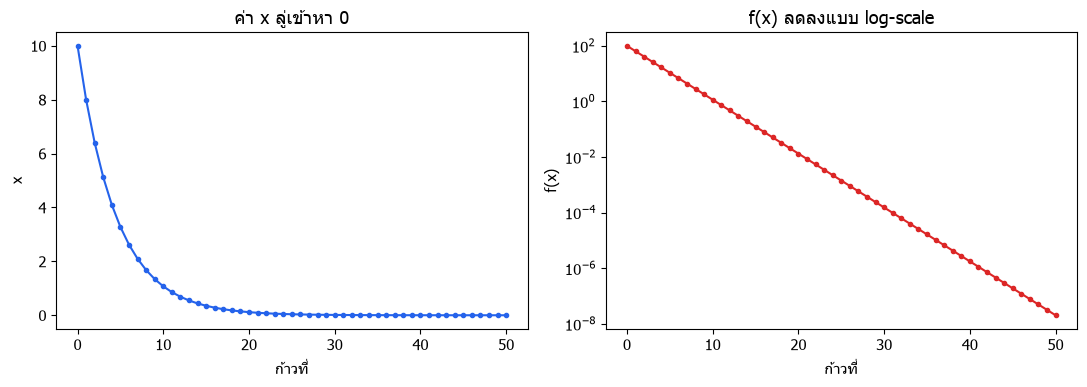

In [6]:
x_current = 10.0
lr = 0.1
trajectory = [x_current]
for _ in range(50):
    grad = f_square_prime(x_current)
    x_current = x_current - lr * grad
    trajectory.append(x_current)

print(f"เริ่มที่ x=10, หลัง 50 ก้าว: x={x_current:.6f}, f(x)={f_square(x_current):.2e}")
assert abs(x_current) < 1e-3
losses = [f_square(x) for x in trajectory]
assert all(losses[i + 1] <= losses[i] for i in range(len(losses) - 1))
print("f(x) ลดลงทุกก้าว (monotonic) และลู่เข้าใกล้จุดต่ำสุดจริง (x=0)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(trajectory, "o-", color="#2563eb", markersize=3)
axes[0].set_xlabel(label("ก้าวที่", "Step"))
axes[0].set_ylabel("x")
axes[0].set_title(label("ค่า x ลู่เข้าหา 0", "x converges to 0"))
axes[1].plot(losses, "o-", color="#dc2626", markersize=3)
axes[1].set_xlabel(label("ก้าวที่", "Step"))
axes[1].set_ylabel("f(x)")
axes[1].set_yscale("log")
axes[1].set_title(label("f(x) ลดลงแบบ log-scale", "f(x) decreases (log scale)"))
plt.tight_layout()
plt.show()

## 7. Learning Rate ส่งผลอย่างไร (Experiment)

สำหรับ $f(x)=x^2$ การอัปเดตคือ $x_{t+1} = x_t - \eta(2x_t) = x_t(1-2\eta)$ ดังนั้นพฤติกรรมขึ้นกับ
$|1-2\eta|$: ถ้า $|1-2\eta|<1$ (คือ $0<\eta<1$) จะลู่เข้า ถ้ามากกว่า 1 จะลู่ออก (diverge)

- $\eta$ เล็กเกินไป (เช่น 0.01) → ลู่เข้าช้า
- $\eta$ กำลังดี (เช่น 0.1) → ลู่เข้าเร็ว เข้าใกล้ 0 อย่างราบรื่น
- $\eta$ ใหญ่แต่ยังลู่เข้า (เช่น 0.9) → **แกว่งข้ามศูนย์ไปมา** (sign สลับ) แต่ขนาดยังลดลงเรื่อยๆ
- $\eta$ ใหญ่เกินไป (เช่น 1.1) → **ลู่ออก** (diverge) ค่ายิ่งอัปเดตยิ่งใหญ่ขึ้น

lr=0.01: เริ่ม x=10.000, จบ x=7.39
lr=0.1: เริ่ม x=10.000, จบ x=0.352
lr=0.9: เริ่ม x=10.000, จบ x=-0.352
lr=1.1: เริ่ม x=10.000, จบ x=-154


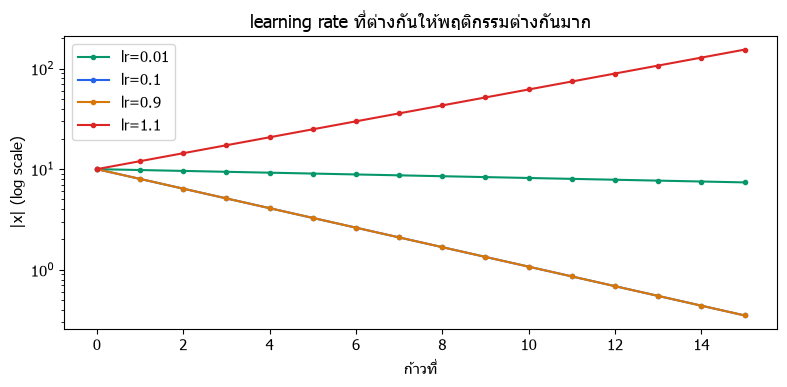

lr=0.1 ลู่เข้าเร็วกว่า lr=0.01 อย่างชัดเจน และ lr=1.1 ลู่ออกจริง (|x| เพิ่มขึ้นแทนที่จะลด)


In [7]:
def run_gd_1d(lr, steps=30, x0=10.0):
    x = x0
    path = [x]
    for _ in range(steps):
        x = x - lr * f_square_prime(x)
        path.append(x)
    return np.array(path)


fig, ax = plt.subplots()
for lr_try, color in zip([0.01, 0.1, 0.9, 1.1], ["#059669", "#2563eb", "#d97706", "#dc2626"]):
    path = run_gd_1d(lr_try, steps=15)
    print(f"lr={lr_try}: เริ่ม x={path[0]:.3f}, จบ x={path[-1]:.3g}")
    ax.plot(np.abs(path), "o-", label=f"lr={lr_try}", color=color, markersize=3)
ax.set_yscale("log")
ax.set_xlabel(label("ก้าวที่", "Step"))
ax.set_ylabel("|x| (log scale)")
ax.legend()
ax.set_title(
    label(
        "learning rate ที่ต่างกันให้พฤติกรรมต่างกันมาก", "Different learning rates behave very differently"
    )
)
plt.tight_layout()
plt.show()

path_small = run_gd_1d(0.01)
path_good = run_gd_1d(0.1)
path_diverge = run_gd_1d(1.1)
assert abs(path_good[-1]) < abs(path_small[-1])
assert abs(path_diverge[-1]) > abs(path_diverge[0])
print("lr=0.1 ลู่เข้าเร็วกว่า lr=0.01 อย่างชัดเจน และ lr=1.1 ลู่ออกจริง (|x| เพิ่มขึ้นแทนที่จะลด)")

## 8. Gradient Descent บนฟังก์ชันหลายตัวแปร

แนวคิดเดียวกันขยายไปยังหลายตัวแปรได้ตรงๆ โดยใช้ gradient vector แทน derivative ตัวเดียว:

$$\mathbf{x}_{t+1} = \mathbf{x}_t - \eta \, \nabla f(\mathbf{x}_t)$$

**ตัวอย่าง:** $f(x,y)=x^2+3y^2$ (ชามที่ไม่กลม แกน $y$ โค้งชันกว่าแกน $x$)
จุดต่ำสุดอยู่ที่ $(0,0)$ เริ่มจาก $(5,5)$

จุดสุดท้าย: [0. 0.] ; f ที่จุดนั้น: 5.871356456934588e-11


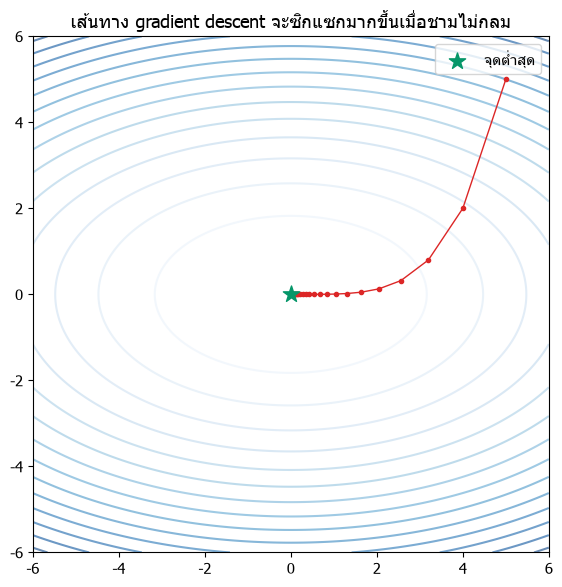

In [8]:
def f_bowl2(xy):
    x, y = xy
    return x**2 + 3 * y**2


def grad_bowl2(xy):
    x, y = xy
    return np.array([2 * x, 6 * y])


point2 = np.array([5.0, 5.0])
lr2 = 0.1
path2 = [point2.copy()]
for _ in range(60):
    point2 = point2 - lr2 * grad_bowl2(point2)
    path2.append(point2.copy())
path2 = np.array(path2)
print("จุดสุดท้าย:", path2[-1], "; f ที่จุดนั้น:", f_bowl2(path2[-1]))
assert np.linalg.norm(path2[-1]) < 1e-2

grid = np.linspace(-6, 6, 200)
X_grid, Y_grid = np.meshgrid(grid, grid)
Z_grid = X_grid**2 + 3 * Y_grid**2
fig, ax = plt.subplots(figsize=(6, 6))
ax.contour(X_grid, Y_grid, Z_grid, levels=15, cmap="Blues", alpha=0.6)
ax.plot(path2[:, 0], path2[:, 1], "o-", color="#dc2626", markersize=3, linewidth=1)
ax.scatter([0], [0], color="#059669", marker="*", s=150, zorder=5, label=label("จุดต่ำสุด", "Minimum"))
ax.set_aspect("equal")
ax.legend()
ax.set_title(
    label(
        "เส้นทาง gradient descent จะซิกแซกมากขึ้นเมื่อชามไม่กลม", "Path zigzags more on an elongated bowl"
    )
)
plt.tight_layout()
plt.show()

## 9. Mini-project: Linear Regression ด้วย Gradient Descent เทียบกับ `lstsq`

`01_vectors_and_matrices.ipynb` เคยหาน้ำหนักด้วย `np.linalg.lstsq` (closed-form solution)
คราวนี้ลองหาน้ำหนักชุดเดียวกันด้วย **gradient descent** แทน โดยใช้ MSE เป็น loss function:

$$L(\theta) = \frac{1}{n}\|X\theta - y\|_2^2, \qquad \nabla L(\theta) = \frac{2}{n}X^\top(X\theta-y)$$

**สำคัญ:** ต้อง standardize feature ก่อน (เทคนิคจาก broadcasting ใน notebook 01) ไม่เช่นนั้น
feature ที่มีสเกลใหญ่ (เช่น พื้นที่บ้านเป็นร้อยตารางเมตร) จะทำให้ gradient ในแกนนั้นใหญ่กว่าแกนอื่นมาก
gradient descent จะลู่เข้าช้าหรือไม่ลู่เข้าเลยถ้าใช้ learning rate เดียวกันทุกแกน

theta จาก gradient descent (บน feature ที่ standardize แล้ว): [ 3.963  1.141  0.452 -0.161]
theta จาก lstsq (บน feature เดียวกัน):                        [ 3.963  1.141  0.452 -0.161]
loss เริ่มต้น: 17.2480, loss สุดท้าย: 0.0139
gradient descent ลู่เข้าหาคำตอบเดียวกับ closed-form solution


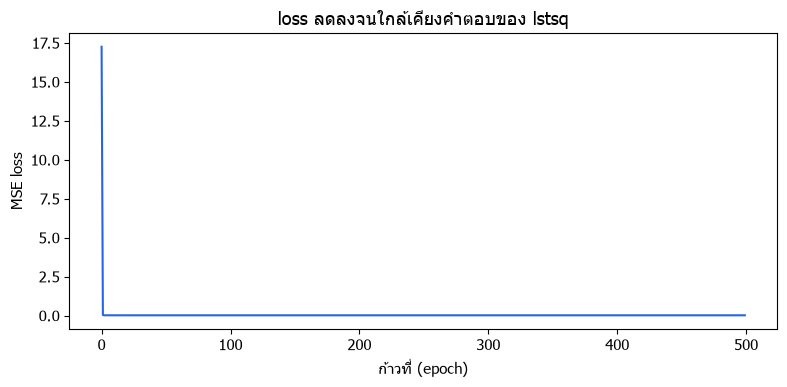

In [9]:
rng = np.random.default_rng(SEED)
n_samples = 200
area = rng.uniform(40, 200, n_samples)
bedrooms = rng.integers(1, 6, n_samples)
age = rng.integers(0, 31, n_samples)
X_raw = np.column_stack([area, bedrooms, age])
true_w = np.array([0.025, 0.30, -0.02])
true_b = 0.4
y = X_raw @ true_w + true_b + rng.normal(0, 0.12, n_samples)

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_scaled = (X_raw - X_mean) / X_std
X_design = np.column_stack([np.ones(n_samples), X_scaled])


def mse_loss(theta, X, y):
    residual = X @ theta - y
    return np.mean(residual**2)


def mse_grad(theta, X, y):
    residual = X @ theta - y
    return (2.0 / len(y)) * (X.T @ residual)


theta_gd = np.zeros(X_design.shape[1])
lr_gd = 0.5
loss_history = []
for _ in range(500):
    loss_history.append(mse_loss(theta_gd, X_design, y))
    theta_gd = theta_gd - lr_gd * mse_grad(theta_gd, X_design, y)

theta_lstsq, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
print("theta จาก gradient descent (บน feature ที่ standardize แล้ว):", theta_gd)
print("theta จาก lstsq (บน feature เดียวกัน):                       ", theta_lstsq)
print(f"loss เริ่มต้น: {loss_history[0]:.4f}, loss สุดท้าย: {loss_history[-1]:.4f}")
np.testing.assert_allclose(theta_gd, theta_lstsq, atol=1e-2)
assert loss_history[-1] < loss_history[0]
assert loss_history[-1] < 0.05
print("gradient descent ลู่เข้าหาคำตอบเดียวกับ closed-form solution")

fig, ax = plt.subplots()
ax.plot(loss_history, color="#2563eb")
ax.set_xlabel(label("ก้าวที่ (epoch)", "Step (epoch)"))
ax.set_ylabel("MSE loss")
ax.set_title(label("loss ลดลงจนใกล้เคียงคำตอบของ lstsq", "Loss converges near the lstsq solution"))
plt.tight_layout()
plt.show()

## 10. แผนที่เชื่อมแนวคิดกับงานจริง

| แนวคิด | โค้ดสำคัญ | ตัวอย่างการใช้งาน |
|---|---|---|
| Derivative | สูตรตรงๆ, central difference | ความชันของฟังก์ชัน ณ จุดหนึ่ง |
| Numerical differentiation | `(f(x+h)-f(x-h))/(2h)` | ตรวจสอบ derivative ที่คำนวณด้วยมือ (gradient checking) |
| Gradient vector | `[df/dx, df/dy]` | ทิศทาง steepest ascent, ตั้งฉากกับ contour |
| Chain rule | `f'(g(x)) * g'(x)` | พื้นฐานของ backpropagation ใน neural network |
| Gradient descent | `x - lr * grad` | ลด loss function เพื่อเรียนรู้พารามิเตอร์โมเดล |
| Learning rate | ค่าคงที่ $\eta$ | ควบคุมความเร็ว/เสถียรภาพของการลู่เข้า |
| Feature standardization | `(X - mean) / std` | ทำให้ gradient descent ลู่เข้าได้เร็วและเสถียร |

**ก่อนใช้ gradient descent ทุกครั้ง:** standardize feature แล้วหรือยัง? ลอง learning rate
หลายค่าแล้วดูว่า loss ลู่เข้าราบรื่นหรือแกว่ง/ลู่ออกหรือไม่? เทียบกับ closed-form solution
(ถ้ามี) เพื่อตรวจสอบความถูกต้องแล้วหรือยัง?

## 11. แบบฝึกหัด — ลองก่อนเปิดเฉลย

ใช้ตัวแปรจากบทเรียนด้านบน และเปลี่ยนค่าในเซลล์ทดลองได้

1. หา derivative ของ $f(x)=x^3$ ด้วยมือ แล้วตรวจกับ central difference ที่ $x=2$
   (คำตอบวิเคราะห์คือ $f'(x)=3x^2$)
2. เปลี่ยนจุดในส่วน 4 จาก `(3, 4)` เป็น `(-2, 5)` แล้วตรวจว่า gradient เชิงวิเคราะห์กับเชิงตัวเลขยังตรงกัน
3. ลอง learning rate `0.99` และ `1.0` ในส่วน 7 (ฟังก์ชัน `run_gd_1d`) สังเกตว่าแต่ละค่าลู่เข้า ลู่ออก
   หรืออยู่กับที่ (เทียบกับเงื่อนไข $|1-2\eta|<1$)
4. ในส่วน 9 ลองไม่ standardize feature (`X_design_no_scale = np.column_stack([np.ones(n_samples), X_raw])`)
   แล้วรัน gradient descent ด้วย `lr_gd` เดิม สังเกตว่า loss ลู่เข้าได้ดีเท่าเดิมหรือไม่
5. เปลี่ยนจำนวนก้าว (epoch) ในส่วน 9 จาก 500 เป็น 50 แล้วดูว่า `theta_gd` ยังใกล้ `theta_lstsq`
   แค่ไหน

ตัวแปรที่ลงท้าย `_exercise` แยกจากตัวอย่างหลัก เพื่อทดลองโดยไม่เขียนทับข้อมูลเดิม

In [10]:
# พื้นที่ทดลอง: ลองเขียนโค้ดของคุณเองก่อนเปิดเฉลยด้านล่าง
x_exercise = 2.0
print("ลองหา f'(x)=3x^2 ที่ x=2 ด้วยมือ แล้วตรวจกับ central difference ของคุณเอง")

ลองหา f'(x)=3x^2 ที่ x=2 ด้วยมือ แล้วตรวจกับ central difference ของคุณเอง


<details>
<summary>เปิดดูแนวทางเฉลยข้อ 1–5</summary>

```python
# ข้อ 1
def f_cube(x):
    return x**3


def f_cube_prime_analytic(x):
    return 3 * x**2


h_step_exercise = 1e-5
x_exercise = 2.0
central_diff_exercise = (f_cube(x_exercise + h_step_exercise) - f_cube(x_exercise - h_step_exercise)) / (
    2 * h_step_exercise
)
np.testing.assert_allclose(central_diff_exercise, f_cube_prime_analytic(x_exercise), atol=1e-3)
print("f'(2) analytical:", f_cube_prime_analytic(x_exercise), "; numerical:", central_diff_exercise)

# ข้อ 2
point_exercise = (-2.0, 5.0)
grad_analytic_exercise = grad_f_bowl_analytic(*point_exercise)
grad_numeric_exercise = grad_f_bowl_numeric(*point_exercise)
np.testing.assert_allclose(grad_analytic_exercise, grad_numeric_exercise, atol=1e-4)
print("gradient ที่ (-2, 5):", grad_analytic_exercise)

# ข้อ 3
for lr_exercise in [0.99, 1.0]:
    path_exercise = run_gd_1d(lr_exercise, steps=15)
    print(f"lr={lr_exercise}: |1-2lr|={abs(1 - 2 * lr_exercise):.3f}, path ท้ายสุด={path_exercise[-5:]}")
# lr=0.99: |1-2(0.99)|=0.98 < 1 → ยังลู่เข้า (ช้าและแกว่ง); lr=1.0: |1-2(1.0)|=1 → x คงที่ไม่ลู่เข้า/ออก (แกว่งเท่าเดิมตลอด)

# ข้อ 4
X_design_no_scale = np.column_stack([np.ones(n_samples), X_raw])
theta_no_scale = np.zeros(X_design_no_scale.shape[1])
loss_no_scale = []
for _ in range(500):
    loss_no_scale.append(mse_loss(theta_no_scale, X_design_no_scale, y))
    theta_no_scale = theta_no_scale - lr_gd * mse_grad(theta_no_scale, X_design_no_scale, y)
print("loss สุดท้ายไม่ standardize:", loss_no_scale[-1], "(เทียบกับ standardize:", loss_history[-1], ")")
# ไม่ standardize มักทำให้ loss สุดท้ายแย่กว่ามากหรือถึงขั้น diverge เป็น inf/nan ด้วย lr เดิม

# ข้อ 5
theta_gd_50 = np.zeros(X_design.shape[1])
for _ in range(50):
    theta_gd_50 = theta_gd_50 - lr_gd * mse_grad(theta_gd_50, X_design, y)
print("theta หลัง 50 epoch:", theta_gd_50)
print("theta หลัง 500 epoch:", theta_gd)
print("theta_lstsq:         ", theta_lstsq)
# 50 epoch มักยังไม่ลู่เข้าเท่า 500 epoch แต่ก็ขึ้นกับ learning rate ที่เลือก
```

</details>

### บันทึกความเข้าใจด้วยคำของคุณเอง

- ถ้าเพื่อนถามว่า gradient descent ทำงานอย่างไร ฉันจะอธิบายเป็นขั้นตอนว่า…
- ฉันจะเลือก learning rate เริ่มต้นอย่างไรในงานจริง และจะรู้ได้อย่างไรว่าเลือกผิด…
- เหตุผลที่ต้อง standardize feature ก่อนใช้ gradient descent ที่ฉันจะอธิบายให้คนอื่นฟังคือ…
- สิ่งที่ฉันยังไม่มั่นใจเกี่ยวกับบทนี้และอยากทบทวนเพิ่มคือ…

## แหล่งอ้างอิงและขอบเขต

เนื้อหาเรียบเรียงใหม่เป็นบทเรียนเชิงปฏิบัติ โค้ด ข้อมูลจำลอง และภาพทั้งหมดสร้างสำหรับ notebook นี้
ไม่ได้คัดลอกข้อความจากบทความต้นฉบับ ตรวจสอบแหล่งข้อมูลเมื่อ **17 กันยายน 2026**

แหล่งอ้างอิง:

1. [Wikipedia — Derivative](https://en.wikipedia.org/wiki/Derivative)
   ใช้เป็นจุดเริ่มต้นสำหรับนิยามลิมิตและความหมายเชิงเรขาคณิต
2. [Wikipedia — Gradient](https://en.wikipedia.org/wiki/Gradient)
   ใช้เป็นจุดเริ่มต้นสำหรับนิยาม gradient vector และความหมาย steepest ascent
3. [Wikipedia — Gradient descent](https://en.wikipedia.org/wiki/Gradient_descent)
   ใช้เป็นจุดเริ่มต้นสำหรับขั้นตอนวิธี; บทเรียนนี้ขยายความด้วยการทดลอง learning rate,
   ปัญหา floating-point ของ numerical differentiation และ mini-project เทียบกับ `lstsq`
   ซึ่งไม่ได้ลงรายละเอียดเชิงโค้ดในบทความต้นฉบับ

เอกสารปฐมภูมิสำหรับตรวจโค้ด:

- [NumPy — linalg.lstsq](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)
- [NumPy — logspace](https://numpy.org/doc/stable/reference/generated/numpy.logspace.html)
- [Matplotlib — contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contour.html)

อ่านต่อในโครงการ: `01_vectors_and_matrices.ipynb` สำหรับพื้นฐาน vector/matrix และ broadcasting
ที่ใช้ในบทนี้ และ `05_linear_regression_numpy.ipynb` สำหรับการต่อยอด linear regression เต็มรูปแบบ